<a href="https://colab.research.google.com/github/santhoshs2004/Implant_Training/blob/main/implant_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models (Classification)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Models (Regression)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Warnings
import warnings
warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv("water_potability.csv")
df.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df.shape

(3276, 10)

**Exploratory data analysis**


In [ ]:
df.isnull().sum()


,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


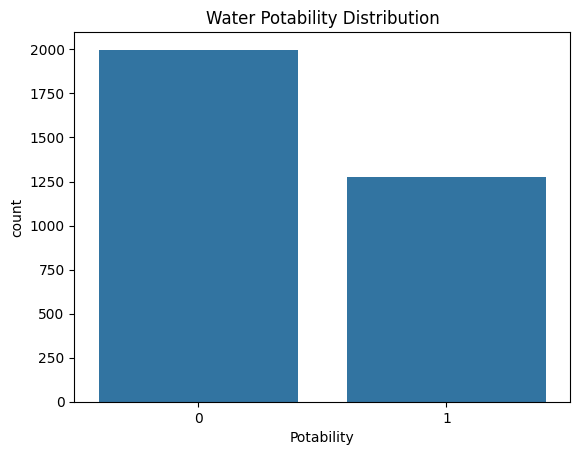

In [ ]:
sns.countplot(x='Potability', data=df)
plt.title("Water Potability Distribution")
plt.show()


In [ ]:
df.describe()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


Feature Correlation


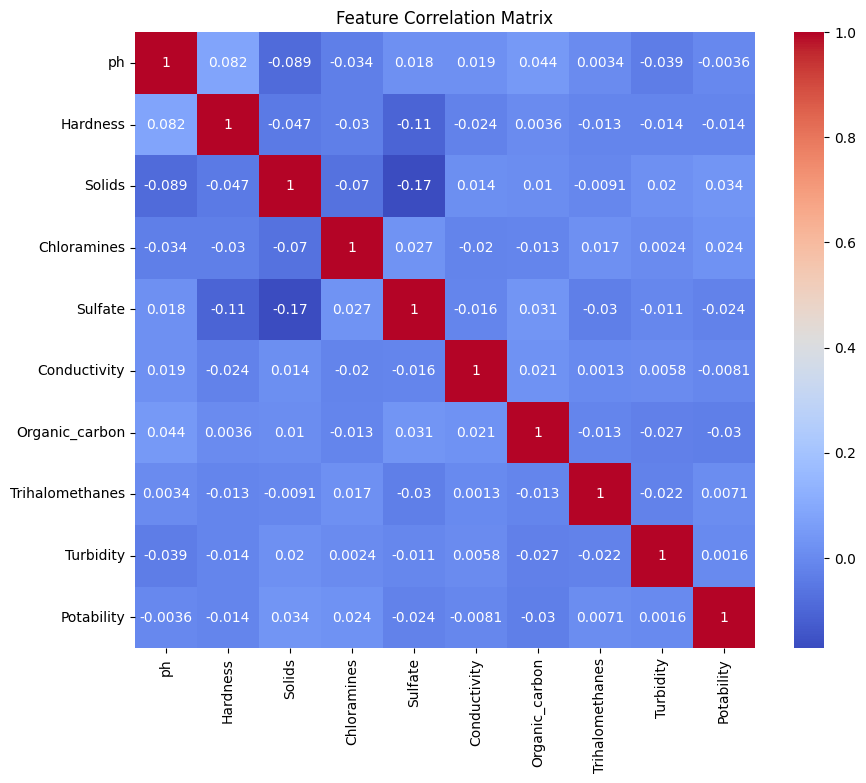

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


**Data Preprocessing**

In [ ]:
X = df.drop("Potability", axis=1)
y = df["Potability"]


In [ ]:
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

X = pd.DataFrame(X_imputed, columns=X.columns)


**Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)


**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Classification models

Logistic Regression


In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]


In [ ]:
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Logistic Regression Results
Accuracy: 0.6097560975609756
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.548564453125

Classification Report:
               precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656



### Random Forest Classifier

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]


In [ ]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest Results
Accuracy: 0.6676829268292683
Precision: 0.75
Recall: 0.22265625
F1 Score: 0.3433734939759036
ROC-AUC: 0.67044921875


**Support Vector Machine (SVM)**

In [ ]:
svm_clf = SVC(kernel='rbf', probability=True)
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)
y_prob_svm = svm_clf.predict_proba(X_test)[:, 1]


In [ ]:
print("SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))


SVM Results
Accuracy: 0.6676829268292683
Precision: 0.69
Recall: 0.26953125
F1 Score: 0.38764044943820225
ROC-AUC: 0.6481054687500001


**Model Comparison Table**

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_svm)
    ]
})

results


,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.609756,0.000000,0.548564
1,Random Forest,0.667683,0.343373,0.670449
2,SVM,0.667683,0.387640,0.648105


**Regression Target**

In [ ]:
who_standards = {
    "pH": 8.5,
    "Hardness": 300,
    "Solids": 1000,
    "Chloramines": 4,
    "Sulfate": 250,
    "Conductivity": 400,
    "Organic_carbon": 10,
    "Trihalomethanes": 80,
    "Turbidity": 5
}

weights = {
    "pH": 0.11,
    "Hardness": 0.11,
    "Solids": 0.10,
    "Chloramines": 0.10,
    "Sulfate": 0.10,
    "Conductivity": 0.10,
    "Organic_carbon": 0.10,
    "Trihalomethanes": 0.10,
    "Turbidity": 0.09
}


**WQI calculation Index**

In [ ]:
def calculate_wqi(row):
    wqi = 0
    total_weight = sum(weights.values())

    for param in who_standards:
        Vi = row[param]
        Si = who_standards[param]
        Qi = (Vi / Si) * 100
        wqi += Qi * weights[param]

    return wqi / total_weight


In [ ]:
who_standards = {
    "ph": 8.5,
    "Hardness": 300,
    "Solids": 1000,
    "Chloramines": 4,
    "Sulfate": 250,
    "Conductivity": 400,
    "Organic_carbon": 10,
    "Trihalomethanes": 80,
    "Turbidity": 5
}

weights = {
    "ph": 0.11, # Corrected from "pH"
    "Hardness": 0.11,
    "Solids": 0.10,
    "Chloramines": 0.10,
    "Sulfate": 0.10,
    "Conductivity": 0.10,
    "Organic_carbon": 0.10,
    "Trihalomethanes": 0.10,
    "Turbidity": 0.09
}

# Original code from the cell
df["WQI"] = df.apply(calculate_wqi, axis=1)
df[["WQI"]].head()

,WQI
0,NaN
1,NaN
2,NaN
3,353.432819
4,285.518707


In [ ]:
def wqi_category(wqi):
    if wqi >= 90:
        return "Excellent"
    elif wqi >= 70:
        return "Good"
    elif wqi >= 50:
        return "Medium"
    elif wqi >= 25:
        return "Poor"
    else:
        return "Very Poor"

df["WQI_Category"] = df["WQI"].apply(wqi_category)
df[["WQI", "WQI_Category"]].head()


,WQI,WQI_Category
0,NaN,Very Poor
1,NaN,Very Poor
2,NaN,Very Poor
3,353.432819,Excellent
4,285.518707,Excellent


# Regression Models

In [ ]:
X_reg = X.copy()
y_reg = df["WQI"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


**Random forest**

In [ ]:
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(Xr_train_cleaned, yr_train_cleaned)
yr_pred_rf_array = rf_reg.predict(Xr_test)

print("Random Forest Regressor")

# Create a Series from the predictions, using Xr_test's index for alignment
yr_pred_rf_series = pd.Series(yr_pred_rf_array, index=Xr_test.index)

# Drop NaN values from yr_test to get the indices of valid rows
valid_indices_test = yr_test.dropna().index
yr_test_cleaned = yr_test.loc[valid_indices_test]

# Now, select predictions corresponding to the cleaned test set using .loc
yr_pred_rf_cleaned = yr_pred_rf_series.loc[valid_indices_test]

print("MAE:", mean_absolute_error(yr_test_cleaned, yr_pred_rf_cleaned))
print("RMSE:", np.sqrt(mean_squared_error(yr_test_cleaned, yr_pred_rf_cleaned)))
print("R2 Score:", r2_score(yr_test_cleaned, yr_pred_rf_cleaned))

Random Forest Regressor
MAE: 4.1077599238311775
RMSE: 5.944621971962959
R2 Score: 0.9959203631601137


**Gradient Boosting Regressor**

In [ ]:
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(Xr_train_cleaned, yr_train_cleaned)

yr_pred_gb = gb_reg.predict(Xr_test)

In [ ]:
print("Gradient Boosting Regressor")

# Create a Series from the predictions, using Xr_test's index for alignment
yr_pred_gb_series = pd.Series(yr_pred_gb, index=Xr_test.index)

# Drop NaN values from yr_test to get the indices of valid rows
valid_indices_test = yr_test.dropna().index
yr_test_cleaned = yr_test.loc[valid_indices_test]

# Now, select predictions corresponding to the cleaned test set using .loc
yr_pred_gb_cleaned = yr_pred_gb_series.loc[valid_indices_test]

print("MAE:", mean_absolute_error(yr_test_cleaned, yr_pred_gb_cleaned))
print("RMSE:", np.sqrt(mean_squared_error(yr_test_cleaned, yr_pred_gb_cleaned)))
print("R2 Score:", r2_score(yr_test_cleaned, yr_pred_gb_cleaned))

Gradient Boosting Regressor
MAE: 3.063832350272493
RMSE: 4.246293393813258
R2 Score: 0.9979184204323541


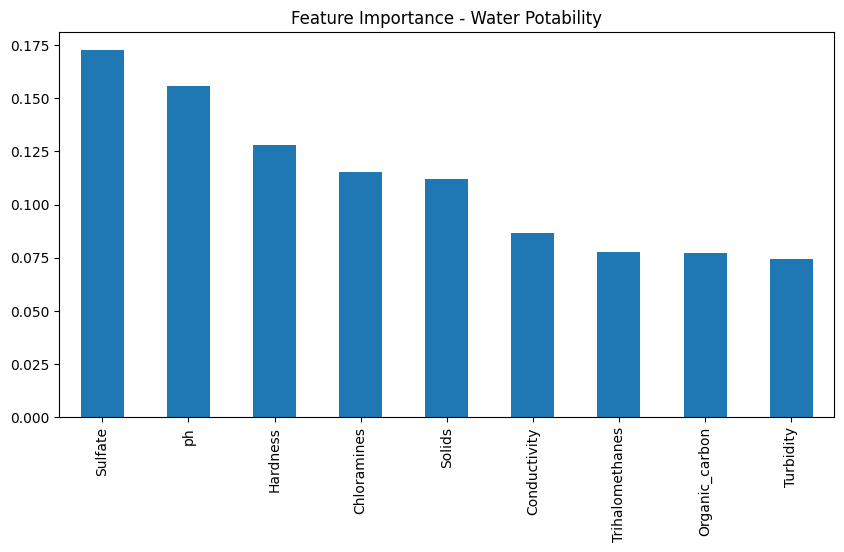

In [ ]:
feature_importance = pd.Series(
    rf_clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance - Water Potability")
plt.show()


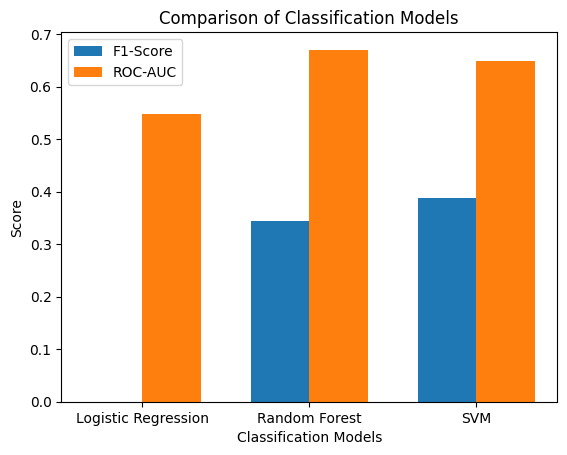

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Classification models
clf_models = [
    "Logistic Regression",
    "Random Forest",
    "SVM"
]

# Metrics (already computed earlier)
f1_scores = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_svm)
]

roc_auc_scores = [
    roc_auc_score(y_test, y_prob_lr),
    roc_auc_score(y_test, y_prob_rf),
    roc_auc_score(y_test, y_prob_svm)
]

x = np.arange(len(clf_models))
width = 0.35

plt.figure()
plt.bar(x - width/2, f1_scores, width, label="F1-Score")
plt.bar(x + width/2, roc_auc_scores, width, label="ROC-AUC")

plt.xlabel("Classification Models")
plt.ylabel("Score")
plt.title("Comparison of Classification Models")
plt.xticks(x, clf_models)
plt.legend()
plt.show()


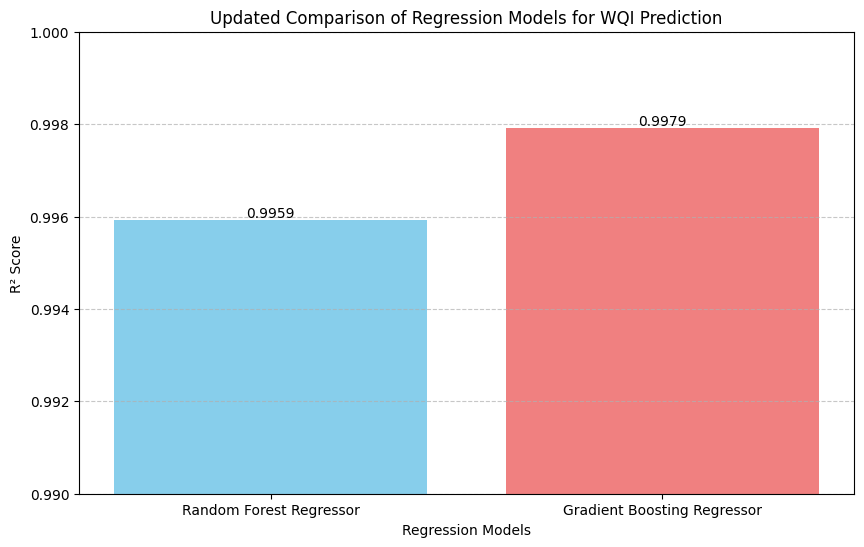

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score

# Regression models (already updated in previous steps)
reg_models = [
    "Random Forest Regressor",
    "Gradient Boosting Regressor"
]

# Drop NaN values from yr_test to get the indices of valid rows
valid_indices_test = yr_test.dropna().index
yr_test_cleaned = yr_test.loc[valid_indices_test]

# Prepare cleaned predictions for each model
yr_pred_rf_series = pd.Series(yr_pred_rf_array, index=Xr_test.index)
yr_pred_rf_cleaned = yr_pred_rf_series.loc[valid_indices_test]

yr_pred_gb_series = pd.Series(yr_pred_gb, index=Xr_test.index)
yr_pred_gb_cleaned = yr_pred_gb_series.loc[valid_indices_test]

# R2 scores (computed with cleaned data)
r2_scores = [
    r2_score(yr_test_cleaned, yr_pred_rf_cleaned),
    r2_score(yr_test_cleaned, yr_pred_gb_cleaned)
]

plt.figure(figsize=(10, 6))
plt.bar(reg_models, r2_scores, color=['skyblue', 'lightcoral'])
plt.xlabel("Regression Models")
plt.ylabel("R² Score")
plt.title("Updated Comparison of Regression Models for WQI Prediction")
plt.ylim(0.99, 1.0) # Set y-axis limits for better visualization of high R2 scores
for i, score in enumerate(r2_scores):
    plt.text(i, score, f'{score:.4f}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()